### Mass-Spring Wave

*From chain.ipynb*

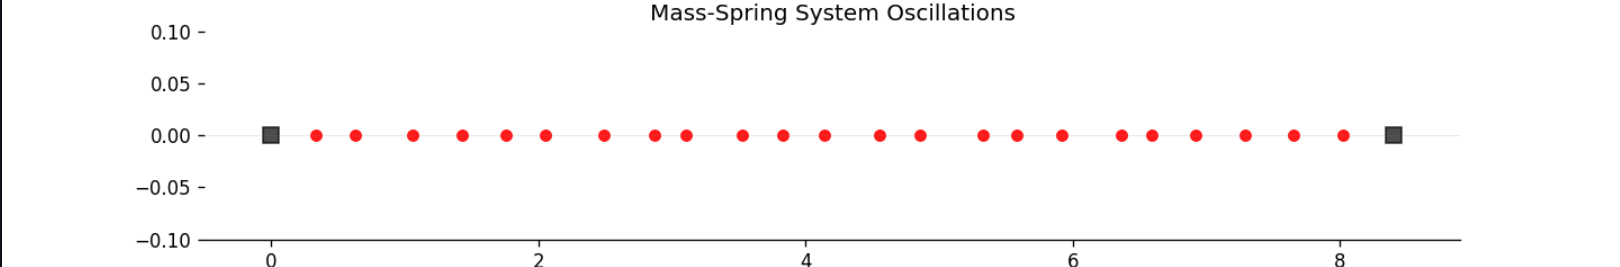

The system consists of $N$ point masses of mass $m$, arranged along a line and connected by ideal springs with spring constant $k$ and zero rest length. The endpoints are fixed. Choosing the equilibrium coordinates $x_j^0 = j a$ with $j = 0, \dots, N-1$, and defining the displacements $u_j = x_j - x_j^0$ for the movable points $j = 1, \dots, N-2$, the equations of motion are obtained from the Lagrangian:

$$
    L  = \frac{1}{2} m \sum_{j=1}^{N-2} \dot{u}_j^2 - \frac{1}{2} k \sum_{j=0}^{N-2} (u_{j+1} - u_j)^2
$$

with $u_0 = u_{N-1} = 0$. Applying the Euler-Lagrange equations yields the system:

$$
    \frac{d^2 u_i}{dt^2} = - \frac{k}{m} \, (2u_i - u_{i-1} - u_{i+1}), \quad i = 1, \dots, N-2
$$

In matrix form, defining the vector $\mathbf{u} = [u_1, u_2, \dots, u_{N-2}]^\top$, the system becomes:

$$
    \frac{d^2 \mathbf{u}}{dt^2} + \omega_{0}^{2} \, \mathbf{K} \, \mathbf{u} = \mathbf{0}
$$

where $\mathbf{K}$ is a symmetric tridiagonal matrix of dimensions $(N-2) \times (N-2)$:

$$
    \mathbf{K} =
        \begin{pmatrix}
            2 & -1 & 0 & \cdots & 0 \\
            -1 & 2 & -1 & \cdots & 0 \\
            0 & -1 & 2 & \cdots & 0 \\
            \vdots & \vdots & \vdots & \ddots & \vdots \\
            0 & 0 & \cdots & -1 & 2
    \end{pmatrix}
$$

and $\omega_0 = \sqrt{k / m}$.

if we define:

- $\tau = \omega_0 t$
- $q_i = u_i / a$

The equation becomes dimensionless:

$$
    \frac{d^2 \mathbf{q}}{d \tau^2} + \mathbf{K} \, \mathbf{q} = \mathbf{0}
$$

In [1]:
# Importing libraries
import numpy as np
from scipy.sparse.linalg import LaplacianNd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
def system_rhs(_, y, K): # System function

    q = y[0:(len(y) // 2)] # Displacement vector
    vel = y[(len(y) // 2):] # Velocity vector

    acc = (K @ q) # @ matrix product operator (- K considered)
    dydt = np.concatenate([vel, acc])

    return dydt

def solver(N, q0_ini, t_span): # It solves the problem using scipy.integrate.solve_ivp()

    K = LaplacianNd( # It creates the (-) K matrix using LaplacianNd from scipy.sparse.linalg
        grid_shape = (N - 2,), # Only inner points
        boundary_conditions = 'dirichlet', # Boundary points are fixed
        dtype = np.float64
    )

    q_ini = np.zeros(N - 2) # All points are localized initially at their equilibrium positions...
    q_ini[0] = q0_ini # ...besides the first one
    y0 = np.concatenate([q_ini, np.zeros(N - 2)])

    solution = solve_ivp(
        fun = system_rhs,
        args = (K,),
        t_span = t_span,
        y0 = y0,
        dense_output = False,
        method = 'RK45',
        rtol = 1e-06,
        atol = 1e-09
    )

    return solution

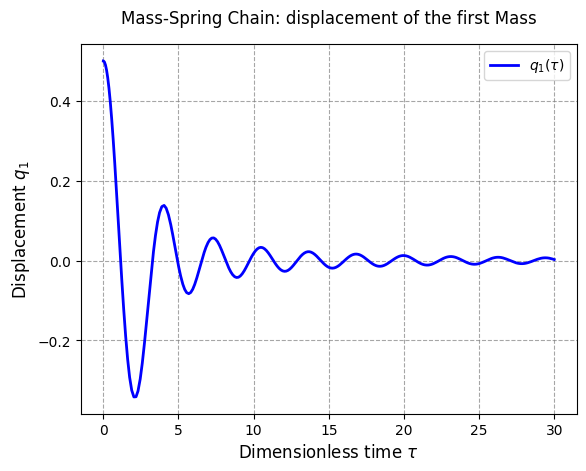

In [3]:
q0 = 0.5
N = 20
tau_span = (0, 30.0)

solution = solver(N, q0, tau_span)

# Plot the displacement of the first mass
plt.plot(solution.t, solution.y[0], color = 'blue', linewidth = 2.0, label = r'$q_1(\tau)$')
plt.xlabel(r'Dimensionless time $\tau$', fontsize = 12)
plt.ylabel(r'Displacement $q_1$', fontsize = 12)
plt.title('Mass-Spring Chain: displacement of the first Mass', fontsize = 12, pad = 15)
plt.grid(True, linestyle = '--', alpha = 0.7, color = 'gray')
plt.legend(fontsize = 10, loc = 'best')
plt.show()